<div style="background: linear-gradient(135deg, #1e293b 0%, #0f172a 100%); padding: 30px; border-radius: 8px; margin-bottom: 25px; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1);">
    <h1 style="color: #f8fafc; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: 700; margin: 0; font-size: 2.2em; letter-spacing: -0.5px;"> Procesamiento global de datos PISA-OECD 🌍
</h1>
    <p style="color: #94a3b8; font-family: 'Segoe UI', sans-serif; margin: 8px 0 0 0; font-size: 1.1em;">Obtención de una muestra representativa global </p>
    
</div>

# 📋 Descripción  

Este cuaderno engloba la problematica de obtener una muestra representativa de todos los datos pisa que permita realizar un estudio riguroso del marco contextual para los informes PISA 2022.

**Column reference** ():

| Column | Type | Meaning |
|---|---|---|
| `CNT` | - | - |
| `CNTSCHID` | - | - |
| `STRATUM` | - | - |
| `W_FSTUWT ` | - | -|
| `SENWT ` | - | - |


In [2]:
import sys
import os

#Indicamos el workspace principal (dos niveles atrás)
sys.path.append(os.path.abspath('../../'))

In [3]:

import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt

# Lectura inicial de los datos

Para la lectura de datos, en vez de el metodo de pandas *read_sas* emplearemos [*pyreadstat*](https://github.com/Roche/pyreadstat/tree/master#reading-files) que presenta una mejor API para el manjo de datos SAS obteniendo el dataframe y sus metadatos

Realizamos la lectura de los metadatos, para obtener el nombre e informacion de las columnas 

In [4]:
#Realizamos la lectura de los datos de interes
df, meta = pyreadstat.read_sas7bdat('../../data/raw/CY08MSP_STU_QQQ.SAS7BDAT', metadataonly=True)

print(f'Numero de filas: {meta.number_rows} \nNumero de columnas: {meta.number_columns}')

Numero de filas: 613744 
Numero de columnas: 1278


In [5]:
#Definimos las columnas de interes para la creación del submuestreo
basic_cols = ['CNT', 'CNTSCHID', 'STRATUM', 'W_FSTUWT','SENWT']

In [6]:
for col in basic_cols:
    # Obtenemos la descripción legible del diccionario de metadatos
    desc = meta.column_names_to_labels[col]
    print(f'{col} | Significado: {desc}')

CNT | Significado: Country code 3-character
CNTSCHID | Significado: Intl. School ID
STRATUM | Significado: Stratum ID 5-character (cnt + original stratum ID)
W_FSTUWT | Significado: FINAL TRIMMED NONRESPONSE ADJUSTED STUDENT WEIGHT
SENWT | Significado: Senate Weight (sum of 5000 per country)


Lectura de las columnas seleccionedas 

In [7]:
df_basic, meta_basic = pyreadstat.read_sas7bdat(
    '../../data/raw/CY08MSP_STU_QQQ.SAS7BDAT', 
    usecols=basic_cols
)

In [8]:
df_basic.shape

(613744, 5)

In [9]:
df_basic.head()

,CNT,CNTSCHID,STRATUM,W_FSTUWT,SENWT
0,ALB,800282.0,ALB03,3.15874,0.55561
1,ALB,800115.0,ALB03,4.34524,0.76431
2,ALB,800242.0,ALB01,7.83860,1.37877
3,ALB,800245.0,ALB08,8.49148,1.49361
4,ALB,800285.0,ALB03,3.70957,0.65249


Las combinaciones por cada alumno registrado por los informes de una escuela viene representado por la siguiente combinacion:


 $$Alumno_n= CNT + CNTSCHID + STRATUM $$

De este modo, si una escuela registrara 10 alumnos, todos ellos compartirían el mismo código. Dado que el objetivo en esta etapa es conservar los valores únicos de cada colegio según su país, colegio y estrato, se realizará una eliminación de duplicados (drop_duplicates) basada en la combinación de estas tres variables. Así, se garantiza que cada centro educativo por país figure una sola vez para poder realizar el submuestreo

In [10]:
#Nos quedamos con escuelas únicas, eliminamos ducplicados enteros
escuelas_unicas=df_basic.drop_duplicates(subset=['CNT','CNTSCHID','STRATUM'])

In [11]:
escuelas_unicas.shape

(21629, 5)

# 🔽 Submuestreo global

In [ ]:
#TODO generar funcion para establecer semilla

# Porcentaje de los datos de la submuestra
fracion = 0.20 

In [28]:
total_escuelas=escuelas_unicas.groupby('CNT')
grupos_escuelas = escuelas_unicas.groupby(['CNT','STRATUM'])

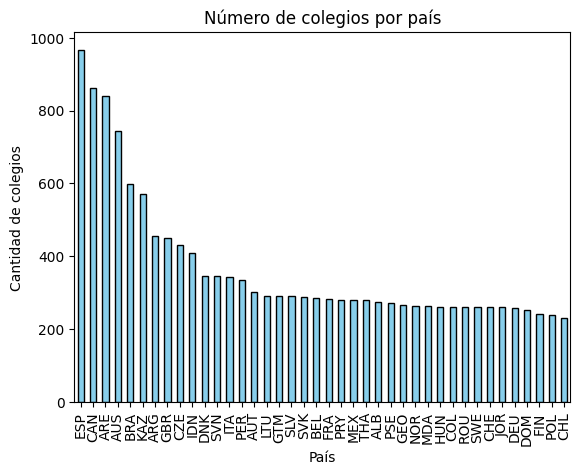

In [22]:
escuelas_unicas.groupby('CNT').size().sort_values(ascending=False).head(40).plot(kind='bar', color='skyblue', edgecolor='black')

# Añadimos títulos para que se entienda mejor
plt.title('Número de colegios por país')
plt.xlabel('País')
plt.ylabel('Cantidad de colegios')

# Esto muestra la gráfica en tu pantalla
plt.show()

In [16]:
grupos = escuelas_unicas.groupby(['CNT', 'STRATUM'])

In [35]:
grupos.size()

CNT  STRATUM
ALB  ALB01      25
     ALB02       5
     ALB03      65
     ALB04      15
     ALB05      38
                ..
VNM  VNM11      26
     VNM12      29
     VNM13       1
     VNM14       4
     VNM15       2
Length: 1014, dtype: int64

In [29]:
#TODO Mejorar redaccion de los datos encontrados

Al analizar el gráfico de barras, destaca significativamente que España (ESP) es uno de los países con mayor volumen de centros educativos en la muestra. Visualmente, supera incluso a países con mayor densidad demográfica, lo que evidencia que el dataset cuenta con una representación notablemente más alta para este territorio en comparación con el resto.

Esta anomalía visual se debe a que España aplica un oversampling (sobremuestra) en este tipo de evaluaciones internacionales: cada una de sus 17 Comunidades Autónomas financia y exige su propia muestra completa para obtener resultados estadísticamente válidos a nivel regional. Al sumarse todas estas muestras independientes, el volumen total de colegios se multiplica exponencialmente en el dataset global.

In [ ]:
#Dataframe intermedio donde se encuentran almacenadas las escuelas divididas por pais y por estrato
df_groups =grupos.size().reset_index(name='total_escuelas')

**_Ceiling_** 

Redondeo hacia arriba

Al calcular la cantidad de escuelas a seleccionar dentro de cada estrato (su 20%), se debe usar una funcion de redondeo hacia arriba para evitar que estratos con pocas escuelas se queden a 0

In [40]:
#Garantizamos que cada estrato tenga representación en la submuestra
df_groups['n_submuestra'] = np.ceil(df_groups['total_escuelas']*fracion).astype(int)

**_Limite de seguridad_** 

Para asegurar los pares de varianza, si el estrato original cuenta con 2 o más escuelas, se deben seleccionar como mínimo 2 escuelas de dicho estrato, aunque sobrepasemos el limite del 20% de la submuestra
.

In [42]:
df_groups['n_submuestra']=np.where(
    (df_groups['total_escuelas']>=2) & (df_groups['n_submuestra'] <2), #Condicion 
    2, #Valor imputado si se cumple
    df_groups['n_submuestra'] #Valor si no se cumple
)

**_Factor de inflacion_** 

El factor de inflación es un multiplicador que se utilizará para reajustar el peso de los alumnos (muestras) por consecuencia de realizar la sumbuestra

Cada estudiante representado en los datos PISA tiene un peso  ($W_{FSTUWT}$) indicando cuantos alumnos del total representa. Al realizar submuestreo y eliminar un porcentaje de los datos, los estudiantes que quedan pierden poder de representación (La ponderaciónya no sería exacta para los datos que tenemos). El factor de inflación "infla"  el peso de los alumnos obtenidos para que representen al resto de compañeros perdidos en el submuestreo.


<div style="
  background: linear-gradient(135deg, rgba(128, 128, 128, 0.25) 0%, rgba(64, 64, 64, 0.15) 100%);
  backdrop-filter: blur(4px);
  -webkit-backdrop-filter: blur(4px);
  border-left: 5px solid rgba(128, 128, 128, 0.6);
  padding: 16px;
  border-radius: 8px;
  color: inherit;
  margin: 20px 0;
">
  <strong style="display: block; margin-bottom: 6px; font-size: 1.1em;">
    💡 Calculo por estrato
  </strong>
   No todos los estratos terminarán teniendo exactamente un 20% de selección. El factor de inflación se calcula de forma dinámica y personalizada para cada estrato
</div>


$$\text{Factor de Inflación} = \frac{N_{\text{escuelas originales en el estrato}}}{N_{\text{escuelas seleccionadas en el estrato}}}$$

In [44]:
df_groups['factor_inflacion']=df_groups['total_escuelas']/df_groups['n_submuestra']

In [47]:
df_groups.set_index(['CNT','STRATUM'])

total_escuelas  n_submuestra  factor_inflacion
CNT STRATUM                                                
ALB ALB01                25             5          5.000000
    ALB02                 5             2          2.500000
    ALB03                65            13          5.000000
    ALB04                15             3          5.000000
    ALB05                38             8          4.750000
...                     ...           ...               ...
VNM VNM11                26             6          4.333333
    VNM12                29             6          4.833333
    VNM13                 1             1          1.000000
    VNM14                 4             2          2.000000
    VNM15                 2             2          1.000000

[1014 rows x 3 columns]

## Seleccion de escuelas

In [ ]:
#Set de escuelas que seran seleccionadas. Se aseguran que son valores unicos mediante un set
escuelas_seleccionadas = set()
factores_dict = {}

In [ ]:
#Para realizar la iteración de forma mas rápida, convertimos en un diccionario el dataframe de los grupos encontrados
#La clave del diccionario sera la tupla de los indices del dataframe, y los valores el resto de elementos del dataframe
groups_dict = df_groups.set_index(['CNT','STRATUM']).to_dict('index')

In [56]:
primera_clave = next(iter(groups_dict))
primer_valor = groups_dict[primera_clave]
print(f"Clave: {primera_clave} | Valor: {primer_valor}")

Clave: ('ALB', 'ALB01') | Valor: {'total_escuelas': 25, 'n_submuestra': 5, 'factor_inflacion': 5.0}


In [ ]:
#Inicializamos el bucle para selecionar las escuelas de cada estrato que conformaran la submuestra

for (pais,estrato), grupo in grupos:

    #Almacenamiento de los datos del estrato
    datos_estrato = groups_dict[(pais,estrato)]
    n_colegios_elegidos = datos_estrato['n_submuestra']

    #Selecion de la muestra dentro del estrato selecioado
    #TODO Quitar lo de random state cuando tengas la funcion de la semilla
    muestra = grupo.sample(n=n_colegios_elegidos,random_state=42)

    #Se actualiza el set con la lista de ls ID de las escuelas que se han selecionado en el estrato
    escuelas_seleccionadas.update(muestra['CNTSCHID'].tolist())
    
    # Guardamos el factor para el ajuste de pesos posterior
    factores_dict[(pais, estrato)] = datos_estrato['factor_inflacion']


    



In [ ]:



# --- PASO 2: EL BUCLE LIGERO (Solo para el sorteo) ---
escuelas_seleccionadas = set()
factores_dict = {}

# Convertimos el DataFrame de matemáticas en un diccionario para iterar a la velocidad de la luz
math_records = df_math.set_index(['CNT', 'STRATUM']).to_dict('index')

# Agrupamos las escuelas reales para sacar los ganadores
grupos = escuelas_unicas.groupby(['CNT', 'STRATUM'])

for (pais, estrato), grupo in grupos:
    # Rescatamos los números ya calculados
    datos_estrato = math_records[(pais, estrato)]
    n_elegir = datos_estrato['a_elegir']
    
    # Sorteo
    muestra = grupo.sample(n=n_elegir, random_state=42)
    escuelas_seleccionadas.update(muestra['CNTSCHID'].tolist())
    
    # Guardamos el factor para el ajuste de pesos posterior
    factores_dict[(pais, estrato)] = datos_estrato['factor_inflacion']

print(f"Sorteo ultrarrápido finalizado. Escuelas elegidas: {len(escuelas_seleccionadas)}")